In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/screensense_clean.csv")
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,10-13,Moderate
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,18+,Moderate
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,14-17,Low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High


In [4]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
Age_Band                                0
Screen_Time_Level                       0
dtype: int64

Histogram of Screen Time Distribution

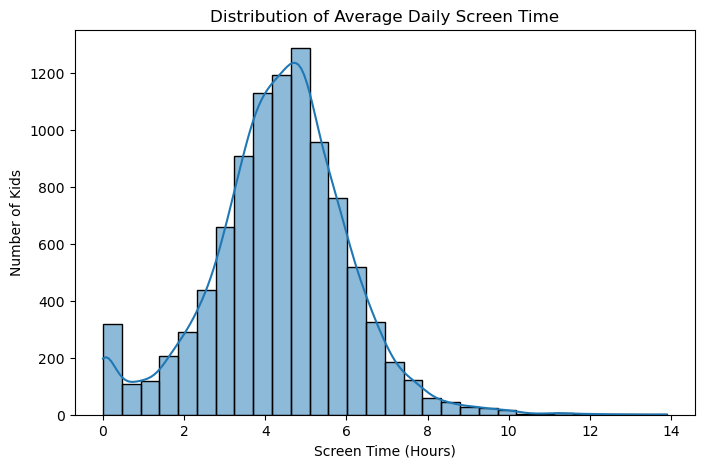

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["Avg_Daily_Screen_Time_hr"], bins=30, kde=True)

plt.title("Distribution of Average Daily Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Number of Kids")

plt.savefig("../outputs/figures/screen_time_distribution.png")

plt.show()

Screen Time Distribution

What the visualization shows
The histogram shows the distribution of average daily screen time among children.

Key pattern observed
Most children spend around 3–6 hours per day on screens.

Why this is important
This indicates that a large portion of children are spending significant time on screens, which may exceed recommended limits and affect health or productivit

Screen Time by Age Band

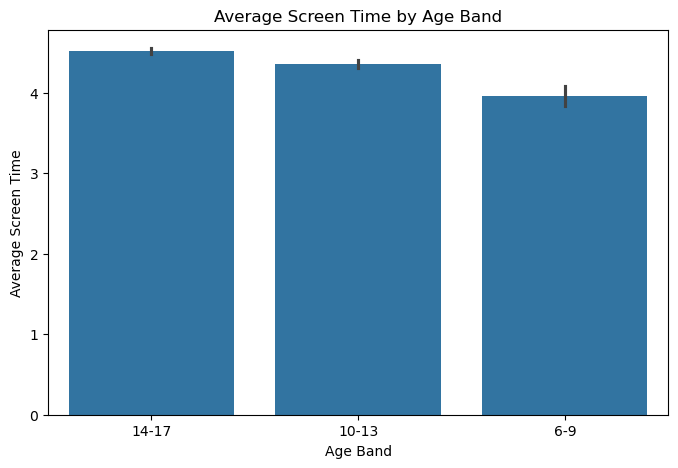

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(x="Age_Band", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time")

plt.savefig("../outputs/figures/screen_time_by_age_band.png")

plt.show()

Screen Time by Age Band

What the visualization shows
This chart compares average screen time across different age groups.

Key pattern observed
Teenagers aged 14–17 show the highest average screen time compared to younger children.

Why this is important
This suggests that screen usage increases with age and older children may require better screen-time monitoring.

Screen Time by Gender (Boxplot)

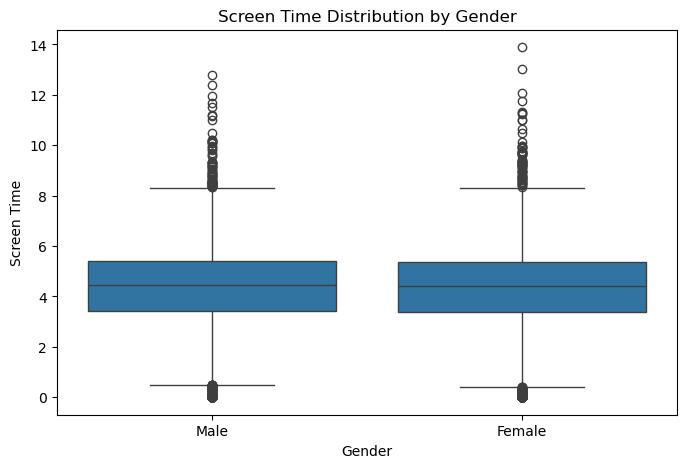

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Screen Time")

plt.savefig("../outputs/figures/screen_time_by_gender.png")

plt.show()

Screen Time by Gender

What the visualization shows
This boxplot compares the distribution of screen time between males and females.

Key pattern observed
Both genders have similar screen time patterns with slight variations in distribution.

Why this is important
Understanding gender differences helps identify whether targeted interventions are needed.

Screen Time by Device

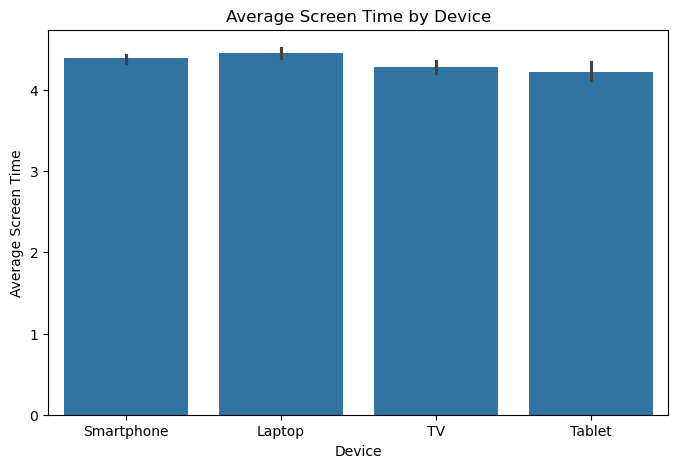

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Average Screen Time by Device")
plt.xlabel("Device")
plt.ylabel("Average Screen Time")

plt.savefig("../outputs/figures/screen_time_by_device.png")

plt.show()

Screen Time by Device

What the visualization shows
This chart shows the average screen time associated with different primary devices.

Key pattern observed
Children who primarily use smartphones tend to have the highest screen exposure.

Why this is important
Smartphones may contribute more to screen overuse compared to other devices.

Heatmap

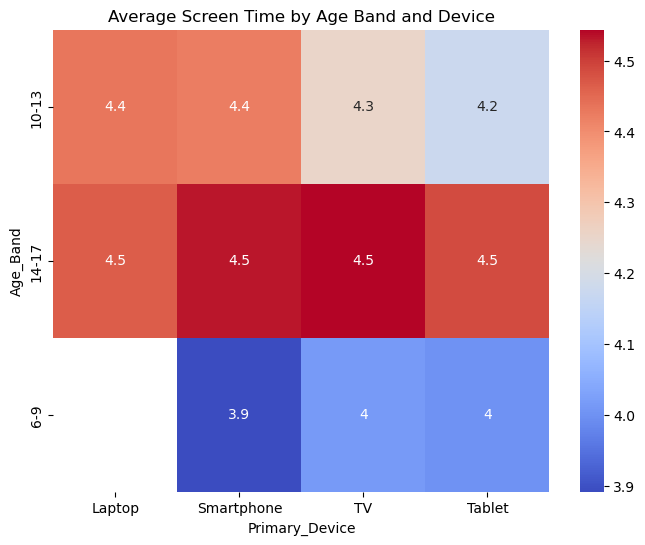

In [9]:
pivot_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm")

plt.title("Average Screen Time by Age Band and Device")

plt.show()

Age Band × Device Heatmap

What the visualization shows
This heatmap displays average screen time for each age group across different device types.

Key pattern observed
Older children using smartphones or TVs show the highest screen time values.

Why this is important
This helps identify high-risk user groups who may exceed recommended screen time limits.

Age Band × Device × Screen Time (Multivariate)

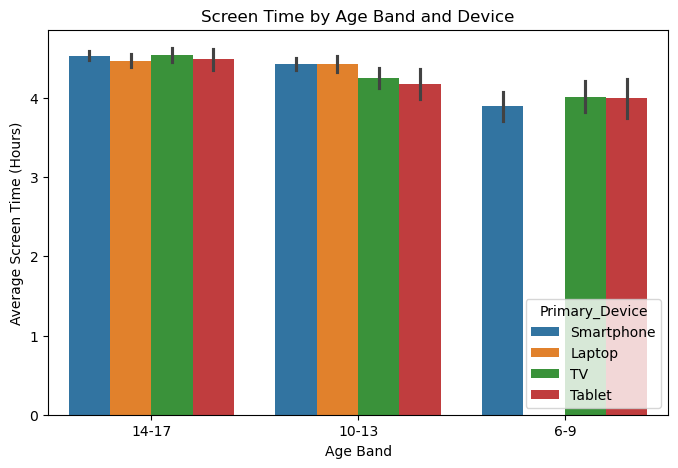

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Age_Band",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Screen Time by Age Band and Device")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")

plt.savefig("../outputs/figures/multivariate_age_device.png")

plt.show()

Insight: Age Band × Device

Teenagers aged 14–17 consistently show higher screen time across all devices.  
Smartphones contribute the most to screen exposure compared to laptops, TVs, and tablets.

Gender × Device × Screen Time

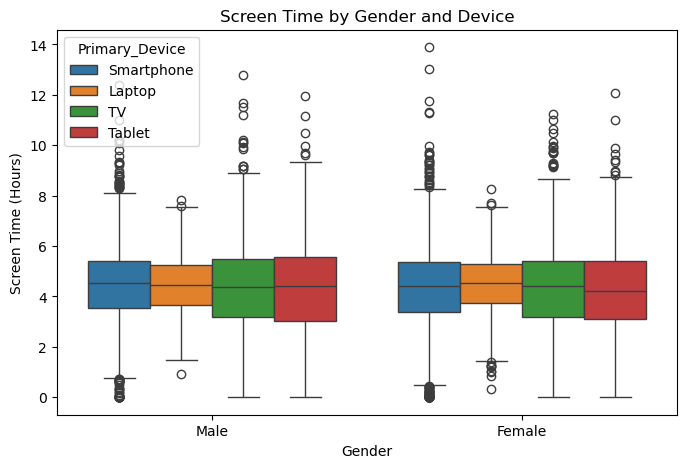

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Screen Time by Gender and Device")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")

plt.savefig("../outputs/figures/multivariate_gender_device.png")

plt.show()

Gender × Device

Both genders show similar screen time patterns, but smartphone users consistently record higher screen exposure.

Urban/Rural × Device × Screen Time

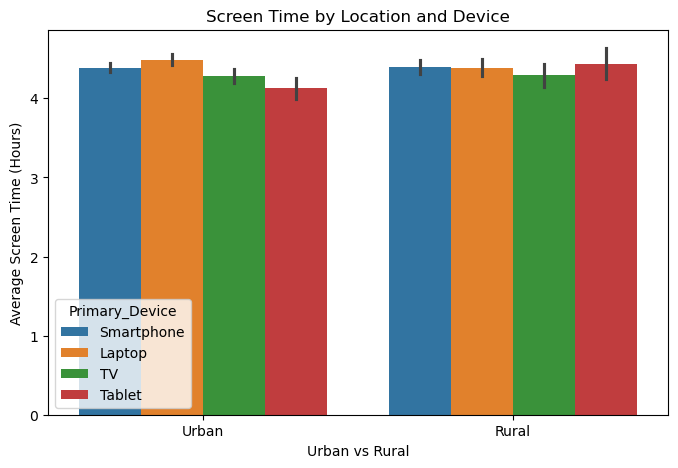

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Urban_or_Rural",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Screen Time by Location and Device")
plt.xlabel("Urban vs Rural")
plt.ylabel("Average Screen Time (Hours)")

plt.savefig("../outputs/figures/multivariate_location_device.png")

plt.show()

Urban vs Rural Screen Usage

Urban children show slightly higher screen time compared to rural children, particularly with smartphone usage.

## Pivot Table Analysis

In [13]:
pivot_table = pd.pivot_table(
    df,
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

print(pivot_table)

Primary_Device    Laptop  Smartphone        TV    Tablet
Age_Band                                                
10-13           4.432627    4.423919  4.251453  4.176112
14-17           4.466824    4.531632  4.543711  4.485863
6-9                  NaN    3.891583  4.014378  3.998766


Heatmap from Pivot Table

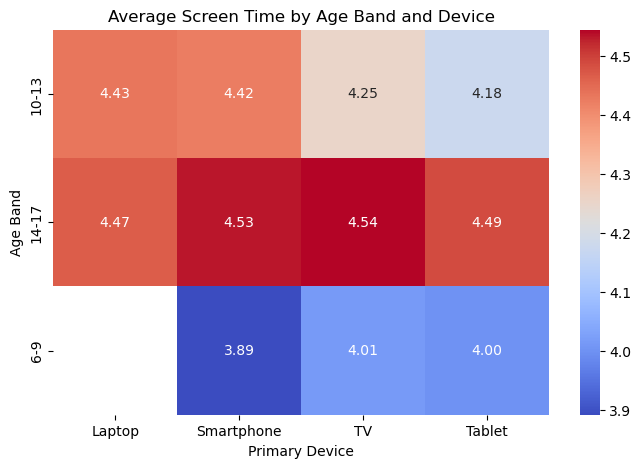

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Average Screen Time by Age Band and Device")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")

plt.savefig("../outputs/figures/pivot_heatmap.png")

plt.show()

Observation
Teenagers (14–17) using smartphones show the highest average screen time.

Screen Time Limit Exceedance

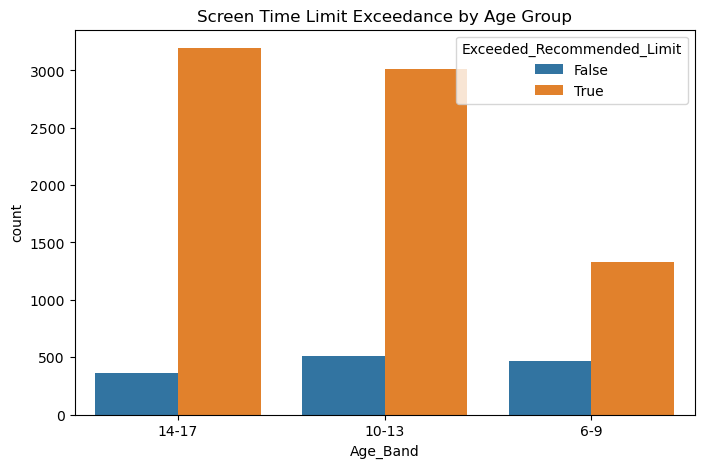

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age_Band",
    hue="Exceeded_Recommended_Limit"
)

plt.title("Screen Time Limit Exceedance by Age Group")

plt.show()

Older children are more likely to exceed recommended screen time limits.

Health Impact Pattern

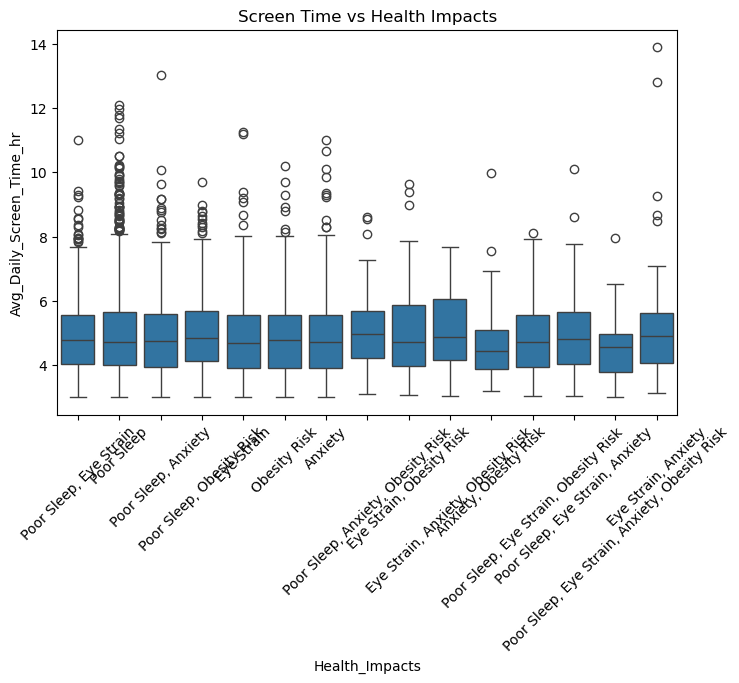

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Health_Impacts",
    y="Avg_Daily_Screen_Time_hr"
)

plt.title("Screen Time vs Health Impacts")

plt.xticks(rotation=45)

plt.show()

Children reporting eye strain or sleep issues show higher screen time levels.

## Key Insights from ScreenSense Analysis

1. Teenagers (14–17) have the highest screen exposure.
2. Smartphones are the primary driver of screen time.
3. Urban children show slightly higher screen usage.
4. Many children exceed recommended screen time limits.
5. Higher screen exposure is associated with health issues like eye strain and poor sleep.

### Limit Exceedance Analysis

In [6]:
# Screen time limit (example: 2 hours)
limit = 2

# Create exceed column
df["Exceeds_Limit"] = df["Avg_Daily_Screen_Time_hr"] > limit

# Check counts
df["Exceeds_Limit"].value_counts()

Exceeds_Limit
True     8880
False     832
Name: count, dtype: int64

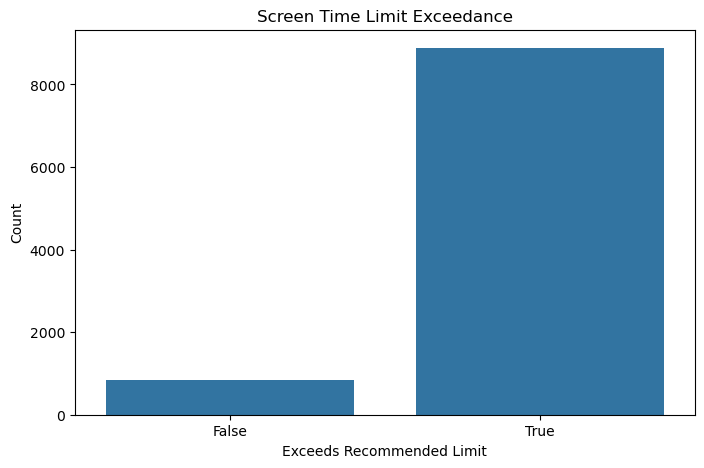

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Exceeds_Limit"
)

plt.title("Screen Time Limit Exceedance")
plt.xlabel("Exceeds Recommended Limit")
plt.ylabel("Count")

plt.savefig("../outputs/figures/screen_time_limit_exceedance.png")
plt.show()

This analysis examines how many children exceed the recommended daily screen time limit.
A threshold of 2 hours per day is used as the recommended limit for healthy screen usage.

By identifying users who exceed this limit, we can understand the extent of excessive screen
usage and its potential impact on health and well-being.